In [1]:
# local imports
from picell_1d import pic_1d, e, m_e, e_0
from dist_gen import *
# external imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
sweep_params: dict = {
	"x_min":			-0.00005,
	"x_max":			 0.00005,
	"v_min":			-10,
	"v_max":			 10,
	"steps_per_pd":		 75,
	"n_frames":			 500,
	"window_res":		 250,
	"f_cells_per_lam_D": 2000,
    "max_field_res":	 5000,
    "fixed_ions":		 True,
    "two_stream":		 False,
	"rho_lim_scale":	 15,
	"E_lim_scale":		 10,
	"ec_lim_margin":	 10,
	"N_e":				 50000,
	"N_i":				 50000,
	"x_pert_amp_e":		 0.2,
	"x_pert_amp_i":		 0,
	"v_th_ratio_e":		 1/5000,
    "v_th_ratio_i":		 1/5000,
    "v_dr_ratio_e":		 0,
	"v_dr_ratio_i":		 0,
    "E_solver":			 1,
    "integration":		 0
}

#pic_1d(sweep_params, show_plot = True, verbose = True)

In [5]:
# Fixed box length
L = 0.0001
# array of total particle counts
#N_s_arr = np.array([100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600, 51200, 102400])
N_s_arr = np.logspace(2, 5, 100).astype(int)
# convert to number densities
n_s_arr = N_s_arr / L
# define number of samples taken at each density
pts_per_val = 1

sweep_data = {
	"densities": [],
	"numbers": [],
	"frequencies": []
}

# sweeping loop
for i in range(len(N_s_arr)):
	sweep_params["x_min"] = -L/2
	sweep_params["x_max"] = L/2
	sweep_params["N_e"] = N_s_arr[i]
	sweep_params["N_i"] = N_s_arr[i]
	for _ in range(pts_per_val):
		result = pic_1d(sweep_params, show_plot = False, verbose = False)
		sweep_data["densities"].append(n_s_arr[i])
		sweep_data["numbers"].append(N_s_arr[i])
		sweep_data["frequencies"].append(result["w_obs"])

Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field resolution to 5000.
Debye-sensitive field resolution breaks max limit. Setting field 

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 100000.

55.16338587695226
56.41460793298621


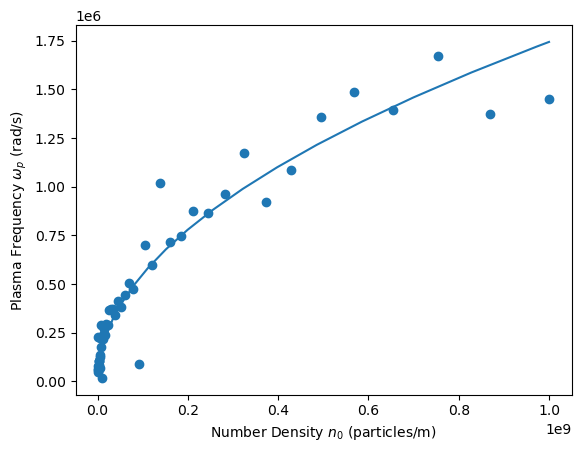

In [ ]:
def sqrt_fit(x, A):
	return A * np.sqrt(x)

plt.scatter(sweep_data["densities"], sweep_data["frequencies"])
plt.xlabel("Number Density $n_0$ (particles/m)")
plt.ylabel("Plasma Frequency $\omega_p$ (rad/s)")
popt, pcov = curve_fit(sqrt_fit, sweep_data["densities"], sweep_data["frequencies"], p0 = [1], maxfev = 10000)
n0_space = np.linspace(min(sweep_data["densities"]), max(sweep_data["densities"]), 500)
plt.plot(n0_space, sqrt_fit(n0_space, popt[0]))
A = popt[0]
print(A)
print(np.sqrt(e**2 / (m_e * e_0)))